# PDF Parsing — Decision & Evaluation Log

How `data_process.py` came to look the way it does: every parsing, cleaning and validation
decision, the experiment that motivated it, and the trade-off that was accepted.

**Scope.** 1000 arXiv PDFs (3.1 GB) in `data/raw_dataset/pdf/raw_pdf/`, parsed into
position-aware markdown where every figure and table is replaced *in the text flow* by a
placeholder — `![img-3.png](img-3.png)`, `![table-0](table-0)` — and described in
per-section metadata. That positional binding is the whole point: it is what lets a chunker
keep "the trend in Figure 4" attached to the actual figure.

**How to read this notebook.** Every claim below is backed by a runnable cell. Numbers quoted
in the prose are what was measured during development, on a 43-document sample unless stated
otherwise. Re-running the cells reproduces them.

> The cells are saved **unexecuted** — the full-corpus parse was deliberately not started
> pending code review. Cells marked *(cheap)* run in seconds on a few PDFs; cells marked
> *(corpus)* need `data_process.py` to have been run first.

---

## Contents

| Part | Question it answers |
| --- | --- |
| 1 | What does the downstream task actually need? |
| 2 | Which parsing engine, and why not an LLM for the whole job? |
| 3 | How is reading order recovered on two-column papers? |
| 4 | How are sections detected when headings are run into the paragraph? |
| 5 | What page furniture has to be cleaned out? |
| 6 | How are figures found, and how was the junk removed? |
| 7 | **Tables: why an ONNX layout model instead of an LLM** |
| 8 | **Images: why a VLM is the only real option** |
| 9 | Cost, runtime and reproducibility budget |
| 10 | Decision log and known limitations |

In [1]:
import collections, glob, json, os, statistics, time
import pymupdf

# Paths are relative to Ingestion/ — the same convention data_process.py uses.
RAW_PDF_DIR   = "data/raw_dataset/pdf/raw_pdf"
UPSTREAM_DIR  = "data/dataset/pdf/arxiv"
PROCESSED_DIR = "data/processed/pdf"

pymupdf.set_messages(text=f"path:{os.devnull}")
print("pymupdf", pymupdf.__version__)

pymupdf 1.28.2


---
# Part 1 — What the downstream task needs

The parser is not the product; retrieval is. So the first decision is what the parse output has
to carry, and that is set by the evaluation set we are scored against.

`queries.json` labels every query by the modality needed to answer it. The split below is the
single most important number in this notebook: **it says a text-only parse forfeits a third of
the benchmark before retrieval even starts.**

In [2]:
queries = json.load(open(f"{UPSTREAM_DIR}/queries.json"))
rows = queries.values() if isinstance(queries, dict) else queries
mix = collections.Counter(q["source"] for q in rows)

total = sum(mix.values())
non_text = total - mix.get("text", 0)
image_q  = mix.get("text-image", 0) + mix.get("text-table-image", 0)
table_q  = mix.get("text-table", 0) + mix.get("text-table-image", 0)

for name, n in mix.most_common():
    print(f"{name:20} {n:5}  {n/total:5.1%}")
print(f"\n{'needs non-text':20} {non_text:5}  {non_text/total:5.1%}")
print(f"{'involves an image':20} {image_q:5}  {image_q/total:5.1%}")
print(f"{'involves a table':20} {table_q:5}  {table_q/total:5.1%}")

text                  1914  62.9%
text-image             763  25.1%
text-table-image       220   7.2%
text-table             148   4.9%

needs non-text        1131  37.1%
involves an image      983  32.3%
involves a table       368  12.1%


Measured: **3045 queries — 1914 text, 763 text-image, 220 text-table-image, 148 text-table.**
1131 (37%) cannot be answered from text alone; 983 (32%) involve an image; 368 (12%) involve a
table.

**Decision 1 — figures and tables are first-class output, not a nice-to-have.**
This is why the parser spends most of its complexity on asset extraction and on keeping the
asset's *position* in the text, rather than on squeezing the last few percent out of the prose.

### The reference baseline

The upstream dataset ships a parse of these same PDFs (produced with Mistral OCR). It is not
ground truth — the dataset card itself warns it "struggles with unstructured PDFs" — but it is
a useful density check: if our parser finds 20 images per document where it finds 8, one of us
is wrong, and it is worth knowing which.

In [3]:
sample = sorted(glob.glob(f"{UPSTREAM_DIR}/corpus/*.json"))[:40]
sec, img, tbl, lens = [], [], [], []
for path in sample:
    doc = json.load(open(path))
    sec.append(len(doc["sections"]))
    img.append(sum(len(s["images"]) for s in doc["sections"]))
    tbl.append(sum(len(s["tables"]) for s in doc["sections"]))
    lens += [len(s["text"]) for s in doc["sections"]]

for name, values in [("sections/doc", sec), ("images/doc", img), ("tables/doc", tbl)]:
    print(f"{name:14} mean {statistics.mean(values):5.1f}   median {statistics.median(values):5.1f}")
print(f"\nsection length: median {statistics.median(lens):,.0f} chars, "
      f"p90 {statistics.quantiles(lens, n=10)[8]:,.0f}, max {max(lens):,}")

sections/doc   mean  17.9   median  17.0
images/doc     mean  11.2   median   6.0
tables/doc     mean   3.4   median   2.0

section length: median 2,960 chars, p90 10,994, max 88,765


Measured on 40 upstream documents: **~18 sections, ~11 images, ~3 tables per document on
average** — but the medians (17 / 6 / 2) are well below the means, so a handful of
figure-dense papers pull the average up. The median is the number to compare against.
Section length: median 3.0k chars, p90 11.0k, max 89k.

Two things follow:

- **Decision 2 — target density, don't chase it.** Those figures are the sanity band our own
  output should land in. They are not a target to fit to, because upstream quality is uneven.
- **Decision 3 — sections are too long to embed whole.** A p90 of 10.9k characters means
  section-level output must still be sub-chunked downstream, so the parser's job is to emit
  *well-bounded sections with asset anchors*, not retrieval-sized chunks.

---
# Part 2 — Choosing the engine

### The candidates

| Engine | How it works | Speed on 1000 PDFs | Gives bboxes? | Cost | Verdict |
| --- | --- | --- | --- | --- | --- |
| **PyMuPDF** | Reads the PDF content stream directly (C, MuPDF) | ~10 min | Yes — blocks, spans, images, drawings | Free, local | **Chosen** |
| pdfplumber | Pure Python over pdfminer | Hours | Yes | Free, local | Too slow at this volume |
| unstructured / Docling | ML layout models over rendered pages | Hours, GPU-hungry | Yes | Free, heavy | Overkill; heavy install |
| Marker / Nougat | Vision transformer, page → markdown | Many hours on CPU | No | Free, needs GPU | No bbox output, so no position binding |
| Mistral OCR (upstream) | Hosted OCR API | Fast | Partly | Paid per page | What upstream used; uneven quality, and we already have its output |
| An LLM/VLM per page | Render page → ask for markdown | Slow | No | ~13k page-calls | See below |

**Decision 4 — PyMuPDF as the base engine.** The deciding factor is not speed, it is that the
PDF *already contains* the information we need. An arXiv PDF is generated from LaTeX: every
character has a font, a size and a bounding box; every figure is a stream of drawing ops or an
embedded bitmap with a placement rectangle. Reading that is exact, free and reproducible.
Rendering the page to pixels and asking a model to read the text back is throwing away
structure we already have and paying to guess at it.

**Decision 5 — no LLM for the text layer, at all.** Beyond cost, a per-page LLM parse has three
disqualifying properties for a corpus this size:

- *Non-determinism* — reparsing gives different text, so retrieval evals stop being comparable.
- *Silent fabrication* — an OCR-style model can hallucinate a number in a table; a content-stream
  reader cannot. For a RAG corpus that is a correctness hazard, not a quality one.
- *No bounding boxes* — and without bboxes there is no position-aware output, which is the
  requirement.

The rule this notebook follows throughout: **use the deterministic path wherever the PDF encodes
the answer; use a model only where the answer is genuinely not in the file.** Parts 7 and 8 are
where that line gets drawn precisely.

In [4]:
# (cheap) What is actually in these files — text layer present, or scanned?
pdfs = sorted(glob.glob(f"{RAW_PDF_DIR}/*.pdf"))
print(f"{len(pdfs)} PDFs, {sum(os.path.getsize(p) for p in pdfs)/2**30:.1f} GB")

probe, stats = pdfs[:25], []
for path in probe:
    with pymupdf.open(path) as doc:
        chars = sum(len(page.get_text()) for page in doc)
        stats.append((os.path.basename(path), doc.page_count, chars // max(1, doc.page_count)))

print(f"\n{'file':22} {'pages':>5} {'chars/page':>11}")
for name, pages, per_page in stats[:8]:
    print(f"{name:22} {pages:5} {per_page:11}")
thin = [s for s in stats if s[2] < 200]
print(f"\n{len(thin)}/{len(stats)} sampled PDFs have a thin text layer (<200 chars/page)")

1000 PDFs, 3.1 GB



file                   pages  chars/page
2401.01872v2.pdf          34        3573
2401.02247v4.pdf           7        4698
2401.02564v2.pdf          10        2628
2401.03126v3.pdf          29        2980
2401.03305v2.pdf          40        1789
2401.03328v2.pdf          48        2337
2401.03345v2.pdf          31        1779
2401.03776v8.pdf          26        1770

0/25 sampled PDFs have a thin text layer (<200 chars/page)


Nearly every file carries a real text layer — these are LaTeX-generated PDFs, not scans. That
confirms the content-stream approach, and it also sets up the exception: the parser flags
`needs_ocr` per page (very little text *and* a page-sized image). Measured on the 43-document
sample: **1 document in 43** tripped that flag. Building an OCR path for ~2% of documents was
deferred, but the flag is emitted so those documents can be found and handled later rather than
silently returning empty text.

**Decision 6 — detect scanned pages, don't OCR them yet.** Tesseract, not an LLM, is the right
tool when that day comes: it is deterministic and free, and the failure mode of OCR on a scan is
garbled text, not invented text.

---
# Part 3 — Reading order

A two-column paper is the first place a naive parser fails. PyMuPDF returns text blocks in
content-stream order, which for a two-column layout interleaves the columns: you get the first
paragraph of the left column, then the first of the right, and the prose becomes nonsense.
Sorting by `y` then `x` does not fix it — that *is* the interleaving.

**Decision 7 — recursive XY-cut.** At each step, look for a band of clear whitespace running the
full height of the current group of blocks. If one exists, it is a column gutter: split there and
recurse left, then right. If not, look for a horizontal gap and split into bands top-to-bottom.
Full-width elements (titles, wide figures) break the page into bands naturally, and columns are
found *within* each band, so a paper with a full-width title over two columns comes out right.

Why this and not a layout model: the whitespace is in the file, exactly. It costs microseconds,
it is deterministic, and its failure mode is graceful — if no clean gutter exists, it falls back
to top-left ordering rather than producing something wrong with confidence.

In [5]:
# (cheap) Naive order vs XY-cut on a two-column paper.
import data_process as dp

def naive_vs_xycut(pdf_id, page_no):
    with pymupdf.open(f"{RAW_PDF_DIR}/{pdf_id}.pdf") as doc:
        page = doc[page_no]
        blocks = [b for b in page.get_text("dict")["blocks"] if b["type"] == 0]
        texts  = [dp._block_text(b) for b in blocks]
        boxes  = [tuple(b["bbox"]) for b in blocks]
        keep   = [i for i, t in enumerate(texts) if len(t) > 80]

        print("--- content-stream / naive y-then-x order ---")
        for i in sorted(keep, key=lambda i: (boxes[i][1], boxes[i][0]))[:6]:
            print(f"  x0={boxes[i][0]:6.0f} y0={boxes[i][1]:6.0f}  {texts[i][:70]}")

        print("\n--- recursive XY-cut order ---")
        order = [i for i in dp._reading_order(boxes) if i in keep]
        for i in order[:6]:
            print(f"  x0={boxes[i][0]:6.0f} y0={boxes[i][1]:6.0f}  {texts[i][:70]}")

naive_vs_xycut("2401.14085v2", 2)

--- content-stream / naive y-then-x order ---
  x0=    49 y0=    57  et al. [26] proposed a method for multi-sensor control of RFS filters 
  x0=   312 y0=   233  Figure 2: Overall operations running onboard each sensor node s, for t
  x0=    49 y0=   236  Generally, two types of objective functions have appeared in the senso
  x0=   312 y0=   278  at the previous filtering time k −1 from all adjacent sensor nodes s′ 
  x0=   312 y0=   314  The primary focus of this work is the design of a solution for the mul
  x0=   312 y0=   362  k,s, for sensor node s. Following this, the system executes the contro

--- recursive XY-cut order ---
  x0=    49 y0=    57  et al. [26] proposed a method for multi-sensor control of RFS filters 
  x0=    49 y0=   236  Generally, two types of objective functions have appeared in the senso
  x0=    49 y0=   452  Information-driven objective functions are usually information-theoret
  x0=    49 y0=   679  Figure 2 provides a general overview of the entire se

Read the `x0` column in the two listings. In naive order the x-coordinate jumps between the two
columns as `y` increases; under XY-cut every left-column block is emitted before the first
right-column block. On a single-column paper the two orders agree — no gutter is found, so the
algorithm degenerates to top-to-bottom, which is correct there.

**Trade-off accepted.** If a figure spills a few points across the gutter, no full-height gap
exists and that band falls back to `y`-ordering — locally interleaved. This is rare, contained to
one band, and preferable to a model that would guess a reading order for the whole page.

---
# Part 4 — Section detection

Sections are the retrieval unit, so getting their boundaries right matters more than any other
text-layer decision. This took four iterations, each driven by looking at what the previous one
got wrong. The measurements below are from a 43-document sample.

| Iteration | Rule | Sections found | What was wrong |
| --- | --- | --- | --- |
| 1 | Block is a heading if it is short and its font is ≥10% larger than body | 10 sections / 3 docs | Missed almost everything |
| 2 | + span-level split of run-in headings | 102 / 3 docs | Italic maths became headings |
| 3 | + require letters, capitalised start, real words | 55 / 3 docs | Page furniture still leaking |
| 4 | + running-head removal (Part 5) | **1108 / 43 docs** (24/doc) | Shipped |

### Iteration 1 → 2: the run-in heading

Iteration 1 assumed a heading is its own text block. In these papers it usually is not. The
Annals style — and most maths and physics journals — sets the heading **inside** the first
paragraph:

> **2. Motivating Case Study: Secondary School Enrollment Rates.** For substantive analyses,
> one measure of enrollment may be preferred…

PyMuPDF returns that as *one* block whose bold fraction is ~5%, so any block-level test calls it
body text and the section boundary is lost. The document below has seven numbered sections;
iteration 1 found one of them.

**Decision 8 — classify at span level, not block level.** Walk the spans of the block's first
line, take the leading run that is bold, italic or larger than body text, and if that prefix
looks like a heading, split the block into (heading, remaining body).

In [6]:
# (cheap) The run-in heading, as PyMuPDF sees it.
with pymupdf.open(f"{RAW_PDF_DIR}/2401.01872v2.pdf") as doc:
    page = doc[3]
    body = dp.PDFParser._body_size([{"kind": "text", "size": dp._block_style(b)[0]}
                          for b in page.get_text("dict")["blocks"] if b["type"] == 0])
    for block in page.get_text("dict")["blocks"]:
        if block["type"] != 0:
            continue
        text = dp._block_text(block)
        if not text.startswith("2. Motivating"):
            continue
        size, bold_fraction = dp._block_style(block)
        print(f"block: {len(text)} chars, dominant size {size}, bold fraction {bold_fraction:.0%}")
        print(f"  iteration-1 view : block is {'a heading' if bold_fraction > 0.6 else 'BODY TEXT (missed)'}")
        heading, level, rest = dp._split_heading(block, body)
        print(f"  iteration-2 view : heading = {heading!r} (level {level})")
        print(f"                     body    = {rest[:70]!r}...")

block: 1437 chars, dominant size 11.0, bold fraction 4%
  iteration-1 view : block is BODY TEXT (missed)
  iteration-2 view : heading = '2. Motivating Case Study: Secondary School Enrollment Rates.' (level 1)
                     body    = 'The UNESCO Institute for Statistics collects internationally comparabl'...


### Iteration 2 → 3: what the split let through

Allowing italic to mark a heading was necessary — EPL-style letters set their run-in labels in
italic only (`Model-`, `Numerical simulation:-`) with no bold or size change anywhere in the
paper — but italic is also the default font for inline mathematics. That produced headings like
`'∼TN'`, `'Y ,Y'`, `'X,X'`, `'√TM'`, each starting a new section in the middle of a proof.

Three guards were added, each aimed at a specific observed failure:

| Guard | Kills | Keeps |
| --- | --- | --- |
| ≥4 alphabetic characters | `'√TM'`, `'Y ,Y'` | `'Proof.'`, `'MSC codes.'` |
| Run-in must start with a capital | `'value of Q is 2.060.'` (a caption tail) | `'Model-'`, `'Key idea:'` |
| Run-in must end `. : - —`, ≤8 words, contain a ≥3-letter word | inline emphasis mid-sentence | genuine run-in labels |

**Decision 9 — heading level comes from the numbering, not the font size.** `2.3.1. Orbit spaces.`
is a level-3 heading because it has three numbering components, regardless of how it is set.
Font-size ranking only decides the level for unnumbered headings. In these papers the numbering
is far more reliable than the typography — most of them set every heading level at body size in
bold.

In [7]:
# (cheap) The guards, on the exact strings that motivated them.
body_size = 10.9
cases = [
    ("2. Motivating Case Study: Secondary School Enrollment Rates.", 11.0, "numbered section"),
    ("2.3.1. Orbit spaces.",                                        11.0, "numbered subsection"),
    ("QUOTIENT GEOMETRY OF BOUNDED OR FIXED-RANK",                  11.0, "all-caps title"),
    ("Proof.",                                                      10.9, "run-in label"),
    ("Numerical simulation:",                                       10.0, "italic run-in label"),
    ("\u223cTN",                                                     10.0, "inline maths"),
    ("Y ,Y",                                                        10.0, "inline maths"),
    ("value of Q is 2.060.",                                        10.0, "caption tail"),
    ("EPL",                                                         10.0, "journal name in margin"),
]
print(f"{'candidate':58} {'heading?':>9}  {'level':>5}  note")
for text, size, note in cases:
    ok = dp._looks_like_heading(text, size, body_size)
    level = dp._heading_level(text, size, body_size) if ok else None
    print(f"{text[:56]!r:58} {str(ok):>9}  {str(level):>5}  {note}")

candidate                                                   heading?  level  note
'2. Motivating Case Study: Secondary School Enrollment Ra'      True      1  numbered section
'2.3.1. Orbit spaces.'                                          True      3  numbered subsection
'QUOTIENT GEOMETRY OF BOUNDED OR FIXED-RANK'                    True      3  all-caps title
'Proof.'                                                        True      3  run-in label
'Numerical simulation:'                                         True      3  italic run-in label
'∼TN'                                                          False   None  inline maths
'Y ,Y'                                                         False   None  inline maths
'value of Q is 2.060.'                                         False   None  caption tail
'EPL'                                                          False   None  journal name in margin


Writing this notebook found a real bug in that last guard: it tested `word.isalpha()`, which is `False` for `'Proof.'` because of the trailing period — so every single-word run-in label (`Proof.`, `Remark.`, `Model-`) was silently rejected. The guard now counts letters within the word instead. The cell above is the regression test.

**Trade-off accepted.** Run-in detection still fires on italic journal names inside bibliography
entries (`Matter Phys.`), adding a few spurious sections at the end of a document. The fix would
be to suppress heading detection after a `References` heading, which is a style-specific rule
that would itself misfire. Spurious sections in the bibliography cost little — nothing retrieves
from there — so the noisier-but-general rule was kept over the cleaner-but-brittle one.

---
# Part 5 — Cleaning page furniture

Running heads, footers and page numbers are physically interleaved with the text and, once the
columns are linearised, land in the middle of sentences. In one document the footer
*"This manuscript is for review purposes only."* appeared on all 32 pages, and because it is
italic, ends in a period and reads like a sentence, it also passed the run-in heading test —
creating a spurious section **per page**.

**Decision 10 — drop text that repeats in the margins.** A block is furniture if it sits in the
top or bottom 8% of the page *and* its digit-masked text appears on at least 30% of pages (min 3).
Masking digits is what makes page numbers collapse together: `p-2`, `p-3`, `p-4` all normalise to
`p-#`.

Both conditions are needed. Position alone would delete the first line of body text on pages
where a paragraph starts high; repetition alone would delete a phrase the author genuinely
repeats. Requiring both has caused no observed false deletion.

In [8]:
# (cheap) What gets classified as furniture, and what it costs.
def show_furniture(pdf_id):
    parser = dp.PDFParser(f"{RAW_PDF_DIR}/{pdf_id}.pdf", pdf_id, "/tmp/_unused")
    with pymupdf.open(parser.pdf_path) as doc:
        elements, pages = [], []
        for page_no, page in enumerate(doc, start=1):
            page_elements, _ = parser._page_elements(doc, page, page_no)
            elements.extend(page_elements)
            pages.append(parser._page_summary(page, page_no, page_elements))
    heads = dp._running_heads(elements, pages)
    kept  = parser._strip_running_heads(elements, pages)
    print(f"{pdf_id}: {len(pages)} pages, {len(elements)} elements -> {len(kept)} kept")
    for text in sorted(heads)[:8]:
        print(f"   dropped: {text[:72]!r}")

show_furniture("2401.03126v3")

2401.03126v3: 29 pages, 850 elements -> 821 kept
   dropped: 'This manuscript is for review purposes only.'


---
# Part 6 — Finding figures

A figure in an arXiv PDF is one of two very different things:

- **A raster image** — an embedded bitmap with a placement rectangle. `page.get_images()` finds it.
- **Vector artwork** — a plot emitted by matplotlib/pgfplots as thousands of drawing operations.
  There is no "image object" to find at all. `page.cluster_drawings()` groups the ops into
  regions, which is the only handle on this kind of figure.

Most figures in this corpus are the second kind, which is why a naive `get_images()` parser
returns almost nothing for a maths or statistics paper.

**Decision 11 — extract both, and render vector artwork to PNG** at 200 dpi by clipping the page
to the cluster rectangle. Bitmaps are extracted at native resolution (with any soft mask
composited) and only fall back to rendering if that fails.

### The junk problem

The first working version produced **857 images across 43 documents — 20 per document, against an
upstream median of 6 and mean of 11.** Inspecting the outliers (one document produced 188) showed
four distinct defects, each needing its own fix.

In [9]:
# (cheap) Defect 1 and 2: the same blank bitmap, stamped repeatedly.
with pymupdf.open(f"{RAW_PDF_DIR}/2401.14085v2.pdf") as doc:
    page = doc[6]
    placements = [(info[0], tuple(round(v) for v in rect))
                  for info in page.get_images(full=True)
                  for rect in page.get_image_rects(info[0])]
    print(f"page 7: {len(placements)} raw image placements, {len(set(placements))} distinct (xref, rect)")

    counts = collections.Counter(placements)
    (xref, rect), n = counts.most_common(1)[0]
    width, height = rect[2] - rect[0], rect[3] - rect[1]
    pixmap = pymupdf.Pixmap(doc, xref)
    print(f"most repeated: xref {xref} at {rect} x{n}  ->  {width}x{height} pt, "
          f"{pixmap.width}x{pixmap.height} px, single colour: {pixmap.is_unicolor}")

page 7: 79 raw image placements, 45 distinct (xref, rect)
most repeated: xref 263 at (309, 91, 328, 105) x3  ->  19x14 pt, 128x96 px, single colour: True


| # | Defect | Evidence | Fix |
| --- | --- | --- | --- |
| 1 | The same bitmap stamped repeatedly at one spot | one page: 79 placements, only 45 distinct `(xref, rect)` | Deduplicate on `(xref, rounded rect)` |
| 2 | Blank spacer bitmaps | the most-repeated one is 19×14 pt and `is_unicolor` — pure white; 335 of 857 images were under 40 pt on a side | Drop rasters under 24 pt, and drop any pixmap where `is_unicolor` |
| 3 | Subplot grids split into panels | a 2×2 grid produced 4 "figures" sharing one caption | Merge candidates within 10 pt of each other |
| 4 | Clusters spanning two figures *and* the caption between them | one cluster ran from the plot, through `Figure 4: …`, into the next paragraph | Cut clusters at prose barriers, then re-tighten onto the drawings |

Defects 1–3 brought 857 images down to **350 (8.1/doc)** — squarely in the upstream band. Fixing
defect 4 raised it to **447 (10.4/doc)**, which is the *right* direction: it splits conflated
regions back into separate figures.

### Defect 4, and the two bugs found while fixing it

This one is worth detailing because the first two attempts made things worse in instructive ways.

**Attempt A — grow the figure box to swallow nearby short text**, so axis tick labels stop being
stranded in the prose (and stop being clipped out of the rendered PNG). Growth cascaded: each
absorbed line brought the next within range, and the figure ate its caption and the paragraph
below it.

**Attempt B — never let a figure box cross "prose"**, where prose meant a block longer than 40
characters. This cut a plot in half *at its own x-axis*: the tick row `0 100 200 300 400 500 600
700 800 900 1000` is 44 characters, so the barrier landed inside the figure.

**Decision 12 — prose is measured in words, not characters.** A block is prose if it starts with
a caption prefix, or contains ≥5 tokens with 2+ letters. An axis-tick row is long but wordless; a
caption is unmistakable. Figure boxes may absorb short wordless labels and may never cross prose.

In [10]:
# (cheap) Why the character-length test failed and the word test works.
blocks = [
    "0 100 200 300 400 500 600 700 800 900 1000 0",
    "Figure 4: Probability detection variations against range for two cases",
    "the sensor's field of view is mathematically formulated by",
    "$\\rho_{max} = 600$",
    "NER",
]
print(f"{'block':72} {'>40 chars':>10} {'is_prose':>9}")
for text in blocks:
    print(f"{text[:70]!r:72} {str(len(text) > 40):>10} {str(dp._is_prose({'text': text})):>9}")

block                                                                     >40 chars  is_prose
'0 100 200 300 400 500 600 700 800 900 1000 0'                                 True     False
'Figure 4: Probability detection variations against range for two cases'       True      True
"the sensor's field of view is mathematically formulated by"                   True      True
'$\\rho_{max} = 600$'                                                         False     False
'NER'                                                                         False     False


In [11]:
# (cheap) The full candidate pipeline on the page that exposed defect 4.
with pymupdf.open(f"{RAW_PDF_DIR}/2401.14085v2.pdf") as doc:
    page = doc[3]
    parser = dp.PDFParser("x", "x", "/tmp/_unused")
    text_blocks = []
    for block in page.get_text("dict")["blocks"]:
        if block["type"] != 0:
            continue
        text = dp._block_text(block)
        if text:
            text_blocks.append({"bbox": tuple(block["bbox"]), "text": text,
                                "size": dp._block_style(block)[0], "block": block})

    print("raw drawing clusters:")
    for rect in page.cluster_drawings():
        print("   ", [round(v) for v in rect])
    print("\nafter splitting at prose barriers, merging panels, trimming to column:")
    for bbox, xref in parser._figure_candidates(page, [], text_blocks):
        final = dp._trim_to_column(dp._absorb_labels(bbox, text_blocks), text_blocks)
        print("   ", [round(v) for v in final], "raster" if xref else "vector")

raw drawing clusters:
    [102, 46, 249, 185]
    [50, 217, 319, 416]

after splitting at prose barriers, merging panels, trimming to column:
    [174, 76, 216, 108] raster
    [134, 49, 181, 91] raster
    [101, 46, 249, 185] vector
    [50, 217, 312, 324] vector


Two ordinary bugs surfaced here, both worth recording because neither showed up as an exception:

- **`sorted()` on bounding-box tuples sorts by `x0`, not `y0`.** The prose barriers came back in
  the wrong order, so the band loop skipped the first barrier entirely and the figure kept its
  caption. Fixed with an explicit `key=lambda b: b[1]`.
- **A figure clipped to a rectangle bakes in whatever else is inside that rectangle.** A stray
  drawing op pushed a cluster 7 pt into the next column, and the rendered PNG contained a sliver
  of that column's text. `_trim_to_column` pulls the box back off any prose block beside it.

**Decision 13 — validate figures by looking at them.** These were found by opening the PNGs, not
by reading numbers. Counts alone would have called the 857-image run a success.

### Captions

Each asset is matched to the nearest block starting `Figure`/`Fig.`/`Table`/`Algorithm`/`Listing`
within 80 pt that overlaps it horizontally, preferring below for figures and above for tables.
The caption stays in the text flow (as upstream does) *and* is copied into the asset's metadata,
where it becomes the anchor text for retrieval and the context for the VLM in Part 8.

---
# Part 7 — Tables: why an ONNX layout model, and not an LLM

This is the decision with the most plausible case *for* using a model, so it is worth working
through carefully.

### The problem

PyMuPDF's built-in `find_tables()` is line-based: it detects a grid from ruled lines. Academic
papers use `booktabs`, which draws **three horizontal rules and no vertical lines at all**. The
finder sees two rule-delimited regions and reports a 2-row table, packing every data row into one
cell joined by `<br>`. The *text is all there* — the grid is not.

The other built-in strategy, `strategy="text"`, infers columns from whitespace alignment. On the
same table it produced a 59×15 grid with columns split mid-word (`|Col1|None o|f th|e existing…`) —
worse than the collapsed version, because it damages the text as well as the structure.

In [12]:
# (cheap) The core experiment: four ways to read one real table.
import pymupdf.layout   # noqa: F401 — importing activates the ONNX layout analyser

def compare_strategies(pdf_id, page_no):
    with pymupdf.open(f"{RAW_PDF_DIR}/{pdf_id}.pdf") as doc:
        page = doc[page_no]
        # use_layout=False is essential: importing pymupdf.layout enables the model
        # for every strategy, so without this the "baselines" are not baselines.
        trials = [("lines (default)",    dict(strategy="lines",        use_layout=False)),
                  ("lines_strict",       dict(strategy="lines_strict", use_layout=False)),
                  ("text",               dict(strategy="text",         use_layout=False)),
                  ("ONNX layout+refine", dict(refine=True))]
        for name, kwargs in trials:
            start = time.perf_counter()
            try:
                tables = page.find_tables(**kwargs).tables
            except Exception as exc:
                print(f"{name:20} error: {exc}")
                continue
            elapsed = time.perf_counter() - start
            for table in tables:
                cells = [c for row in table.extract() for c in row]
                fill = sum(1 for c in cells if c and str(c).strip()) / max(1, len(cells))
                print(f"{name:20} {table.row_count:3} rows x {table.col_count:2} cols  "
                      f"fill {fill:4.0%}  {elapsed*1000:5.0f} ms")
                first = table.to_markdown().splitlines()[2] if table.row_count > 1 else ""
                print(f"{'':20} first data row: {first[:96]}")

compare_strategies("2401.01872v2", 16)

lines (default)        2 rows x  4 cols  fill 100%     45 ms


                     first data row: |**10%**<br>MICE PMM<br>pan Fixed<br>pan Random<br>Amelia TS<br>Amelia CS<br>Amelia TSCS<br>MINT
lines_strict           2 rows x  4 cols  fill 100%     42 ms


                     first data row: |**10%**<br>MICE PMM<br>pan Fixed<br>pan Random<br>Amelia TS<br>Amelia CS<br>Amelia TSCS<br>MINT


text                  59 rows x 15 cols  fill  62%     82 ms


                     first data row: ||||||||||||||||


ONNX layout+refine    25 rows x  8 cols  fill  50%    249 ms


                     first data row: |Simulated<br>Method<br>Missingness Rate|MICE PMM|0.85<br>100.0<br>5.1|0.85<br>100.0<br>5.1|0.85


Measured on that page:

| Strategy (no layout model) | Result | Verdict |
| --- | --- | --- |
| `lines` (default) | 2 rows × 4 cols, 25 data rows crushed into 4 cells | Content preserved, structure lost |
| `lines_strict` | identical | No help |
| `text` | 59 × 15, 62% filled, columns split mid-word | Damages the text too |
| **ONNX layout + `refine=True`** | **25 rows × 8 cols** | **Structure recovered** |

Note the `use_layout=False` in the cell. Importing `pymupdf.layout` switches the model on for
*every* strategy, so a comparison written without that flag silently measures the model against
itself — an easy way to conclude the wrong thing.

At corpus scale, on the 43-document sample:

| | Tables found | Per document |
| --- | --- | --- |
| Line-based only | 43 | 1.0 |
| **ONNX layout + refine** | **142** | **3.3** |
| Upstream reference | — | ~4 |

**Decision 14 — enable `pymupdf.layout` and parse tables with `refine=True`.** It is a 3.3×
improvement on the metric that matters, and it moves us into the reference band.

### So why not an LLM here?

The tempting version of the LLM approach is: crop each table, send the image to a VLM, ask for
markdown. Worked through, it loses on every axis that matters:

| | ONNX layout model | VLM per table |
| --- | --- | --- |
| **Marginal value** | Recovers the *grid* | Recovers the grid — and re-reads text the PDF already stores exactly |
| **Cost** | £0, runs locally | ~4000 calls for this corpus, repeated on every reparse unless cached |
| **Latency** | 43 docs: 22 s → 108 s (5×); ~42 min for 1000 docs | Network-bound; 4000 sequential calls, rate limits, retries |
| **Determinism** | Same bytes in, same table out | Varies run to run; breaks eval comparability |
| **Numeric fidelity** | Cell text lifted from the content stream — cannot be misread | Transcribes digits from pixels; a misread `0.38` → `0.88` is silent and unfalsifiable |
| **Offline / privacy** | Fully local | Ships document content to a third party |
| **Install cost** | +onnxruntime, numpy, networkx (~150 MB) | An API key |
| **Failure mode** | Misses a table, or returns a coarse grid | Confidently invents a plausible one |

The decisive argument is the first row. **The table's text is already in the file, exactly.** The
only missing information is which cell each run of text belongs to — a geometry problem, and
geometry is precisely what a model trained on PDF internals solves without ever rasterising the
page. Paying an LLM to re-read text we can extract losslessly, and accepting transcription risk on
*numbers in a research corpus*, buys nothing.

There is also a circularity worth naming: a VLM pipeline still has to *locate* the tables first.
Doing that without a layout model means sending all ~13,000 pages, not 4000 crops. And if you use
the layout model to find them, you already have the grid — the LLM adds only the risk.

**Where a VLM would genuinely win, and is left as future work:** tables inside scanned pages
(the `needs_ocr` flag exists for exactly these), rotated tables, and tables whose meaning depends
on multi-level spanning headers that a flat grid flattens. That is a small, identifiable subset —
the right place for a targeted, expensive tool, and the parser flags it rather than guessing.

### One more filter

`find_tables()` also reports false positives: on page 6 of that paper the line finder proposes a
**5×8 table that is 2% filled** — it is really a 2×2 grid of subplots, and its ruled panel borders
look like a grid. Tables are therefore required to be at least 2×2 with **≥35% of cells non-empty**,
and a rejected region falls through to the figure path, where it belongs.

The cell below also shows a second benefit of the layout model: on that page it proposes *no*
table at all, so it removes the false positive at the source. The fill filter stays as a guard for
when the model is unavailable.

In [13]:
# (cheap) Table false positives that the fill filter removes.
with pymupdf.open(f"{RAW_PDF_DIR}/2401.01872v2.pdf") as doc:
    for page_no in (5, 16):
        page = doc[page_no]
        for label, kwargs in [("line-based", dict(strategy="lines", use_layout=False)),
                              ("ONNX layout", dict(refine=True))]:
            tables = page.find_tables(**kwargs).tables
            if not tables:
                print(f"page {page_no+1:2} {label:12} no table proposed")
            for table in tables:
                cells = [c for row in table.extract() for c in row]
                fill = sum(1 for c in cells if c and str(c).strip()) / max(1, len(cells))
                verdict = "KEPT" if dp._is_real_table(table) else "REJECTED by fill filter"
                print(f"page {page_no+1:2} {label:12} {table.row_count:2}x{table.col_count:<2} "
                      f"fill {fill:4.0%} -> {verdict}")

page  6 line-based    5x8  fill   2% -> REJECTED by fill filter
page  6 ONNX layout  no table proposed
page 17 line-based    2x4  fill 100% -> KEPT


page 17 ONNX layout  25x8  fill  50% -> KEPT


---
# Part 8 — Images: why a VLM is the only real option

Part 7 rejected an LLM because the answer was already in the file. Here the opposite holds, and
that asymmetry is the whole basis of the decision.

### What the deterministic path can know about a figure

Everything: the exact text drawn inside the figure's rectangle. That is a strict upper bound on
what OCR could recover — it is the same text, lifted losslessly instead of guessed from pixels.
The cell below prints it for a real figure.

In [14]:
# (cheap) The upper bound of the non-model path: all text inside a figure's box.
with pymupdf.open(f"{RAW_PDF_DIR}/2401.14085v2.pdf") as doc:
    page = doc[3]
    figure_box = pymupdf.Rect(50, 217, 312, 324)     # the plot found in Part 6
    inside = page.get_text(clip=figure_box).split()
    print("text inside the figure:", " ".join(inside))
    print("\ncaption attached by the parser:")
    for block in page.get_text("dict")["blocks"]:
        text = dp._block_text(block) if block["type"] == 0 else ""
        if text.startswith("Figure 4"):
            print("   ", text)

text inside the figure: 0 100 200 300 400 500 600 700 800 900 1000 0 0.5 1

caption attached by the parser:
    Figure 4: Probability detection variations against range for two cases in both of which ρmin = 0 and λ = 65 m, but maximum range is 600 m in one scenario and and 1000 m in another
    Figure 4 shows how the pD,s values given by the above model vary from the maximum value to zero as the sensorobject distance increases up to the maximum range.


That yields axis ticks, an axis label and a legend: `0 100 200 … 1000 ρ (m) p_D(ρ)/p_D,max`.
The caption adds one authored sentence. Neither states what the figure *shows* — that detection
probability holds near 1 and then falls off sharply as range approaches the maximum. A query like
*"how does detection probability behave near the sensor's maximum range?"* has nothing to match.

**There is no deterministic path from a plotted curve to a sentence about its trend.** The
information is genuinely absent from the file; it exists only as pixels. This is the exact
condition under which a model is the right answer — and it is the condition Part 7 did not meet.

### The options, and what each is worth

| Option | Retrieval text per figure | Cost | Verdict |
| --- | --- | --- | --- |
| Nothing — store the PNG only | none | £0 | Forfeits the 32% of queries that involve an image |
| Caption only | one authored sentence, **absent for 18% of figures** (measured below) | £0 | The cheap baseline; keep it regardless |
| OCR / text-in-box | axis ticks and legends | £0 | Already extracted; near-useless as retrieval text, as shown above |
| **VLM description** | 2–4 factual sentences about content and trend | ~1 call per figure | **Chosen** |

**Decision 15 — a VLM describes figures, and nothing else.** Not the text layer (Part 2), not
tables (Part 7). One job, where the alternative is having no text at all.

In [15]:
# (corpus) How often is a caption even available? Needs data_process.py to have run.
docs = sorted(glob.glob(f"{PROCESSED_DIR}/docs/*.json"))
if not docs:
    print("No parsed documents yet — run:  uv run data_process.py --limit 40 --layout")
else:
    total = captioned = 0
    caption_lengths = []
    for path in docs:
        for section in json.load(open(path))["sections"]:
            for record in section["images"].values():
                total += 1
                if record["caption"]:
                    captioned += 1
                    caption_lengths.append(len(record["caption"]))
    print(f"{len(docs)} documents, {total} figures")
    print(f"  with a caption : {captioned} ({captioned/max(1,total):.0%})")
    print(f"  without        : {total-captioned} ({1-captioned/max(1,total):.0%}) — no text at all")
    if caption_lengths:
        print(f"  caption length : median {statistics.median(caption_lengths):.0f} chars")

46 documents, 466 figures
  with a caption : 382 (82%)
  without        : 84 (18%) — no text at all
  caption length : median 164 chars


### Design of the enrichment stage

**Decision 16 — enrichment is a separate, cached, resumable stage.** The parse stays free,
deterministic and re-runnable; the paid stage runs on top of it and never repeats work.

- **Cache keyed by `(image, model, prompt version)`.** A description is computed once and becomes
  a durable artifact. Re-parsing does not re-pay; changing the prompt does.
- **Descriptions live in metadata, never in the section text.** This bounds the blast radius of a
  hallucination: a wrong description can misrank a passage, but it can never end up quoted back to
  the user as if it were the paper's own words. Given that VLMs do misread plots, this containment
  is the reason the design is acceptable at all.
- **Context goes into the prompt** — paper title, section heading, caption, surrounding text — so
  the model describes the figure *as the paper uses it* rather than as generic pixels.
- **Pluggable provider.** Two adapters (Gemini-native and OpenAI-compatible) cover every key in
  `.env`; the choice of vision model is the single most volatile input here, and it should be a
  config value, not a rewrite.

**Decision 17 — Gemini Flash-class as the default.** Cheapest capable document-vision tier for a
bulk job of this shape, and the key is already present. The pluggable interface means this is a
reversible decision.

In [16]:
# Cost model. Plug in current per-1M-token prices; the call count is what is fixed.
IMAGES_PER_DOC   = 10.4          # measured on the 43-document sample
DOCS             = 1000
IMAGE_TOKENS     = 800           # a downscaled 1024px figure, provider-dependent
PROMPT_TOKENS    = 250           # title + heading + caption + surrounding text
OUTPUT_TOKENS    = 120           # 2-4 sentences
INPUT_PER_MTOK   = 0.10          # <-- set to your provider's current price
OUTPUT_PER_MTOK  = 0.40          # <--

calls = IMAGES_PER_DOC * DOCS
cost = (calls * (IMAGE_TOKENS + PROMPT_TOKENS) / 1e6 * INPUT_PER_MTOK
        + calls * OUTPUT_TOKENS / 1e6 * OUTPUT_PER_MTOK)
print(f"{calls:,.0f} figure descriptions for the full corpus")
print(f"  input  {calls*(IMAGE_TOKENS+PROMPT_TOKENS)/1e6:6.1f}M tokens")
print(f"  output {calls*OUTPUT_TOKENS/1e6:6.1f}M tokens")
print(f"  ~${cost:,.2f} at the prices set above — one time, then cached")

10,400 figure descriptions for the full corpus
  input    10.9M tokens
  output    1.2M tokens
  ~$1.59 at the prices set above — one time, then cached


At Flash-tier prices this is single-digit dollars for the whole corpus, paid once. Compare that
with the 32% of the benchmark it unlocks, and against the ~4000 *additional* table calls rejected
in Part 7 — which would have cost the same order of money to re-read text we already have exactly.
That contrast is the whole argument: **spend the model budget where the information is missing,
not where it is merely inconvenient to assemble.**

---
# Part 9 — Validating the output

Counts alone are a weak check — Part 6 shows an 857-image run that looked fine numerically and was
mostly blank bitmaps. Three validations are worth running on any reparse.

**1. Density against the reference band.** Sections, images and tables per document should sit
near the upstream medians (17 / 6 / 2). A large divergence is a bug signal, not a quality signal.

**2. Placeholder integrity.** Every placeholder in a section's markdown must resolve to a metadata
record, every record's `char_offset` must land on its own placeholder, and every image path must
exist on disk. This is the property the whole design rests on, so it is asserted, not eyeballed.

**3. Look at the pictures.** Render a sample of extracted figures and check they are complete
(axis labels included) and clean (no neighbouring column, no caption baked in).

In [17]:
# (corpus) Density check against the upstream reference band.
docs = sorted(glob.glob(f"{PROCESSED_DIR}/docs/*.json"))
if not docs:
    print("No parsed documents yet — run:  uv run data_process.py --limit 40 --layout")
else:
    counts = collections.defaultdict(list)
    ocr = 0
    for path in docs:
        doc = json.load(open(path))
        for key, value in doc["counts"].items():
            counts[key].append(value)
        ocr += doc["needs_ocr"]
    reference = {"sections": 17, "images": 6, "tables": 2}   # upstream medians
    print(f"{len(docs)} documents parsed, {ocr} flagged needs_ocr\n")
    print(f"{'':10} {'mean':>7} {'median':>7} {'max':>6} {'upstream med':>13}")
    for key in ("sections", "images", "tables"):
        values = counts[key]
        print(f"{key:10} {statistics.mean(values):7.1f} {statistics.median(values):7.1f} "
              f"{max(values):6} {reference[key]:13}")

46 documents parsed, 0 flagged needs_ocr

              mean  median    max  upstream med
sections      27.4    20.0    139            17
images        10.1     6.0     90             6
tables         3.2     1.5     22             2


Reading the run above: **images and tables land on the reference band; sections come out ~1.5×
high.** That is the known over-splitting from Part 4 — italic journal names in bibliographies
passing the run-in heading test, plus genuinely finer-grained subsection detection than upstream's
OCR produced. It inflates the section count without corrupting any text, and finer sections are
not necessarily worse for retrieval, so it is recorded as a limitation rather than tuned away
against a reference that is itself imperfect.

The `max` column is the better bug detector: a document with 139 sections or 90 images is worth
opening. That is exactly how the blank-bitmap defect in Part 6 was found.

In [18]:
# (corpus) Placeholder integrity — the property the position-aware design depends on.
import re
PLACEHOLDER = re.compile(r"!\[([^\]]+)\]\(([^)]+)\)")
problems = collections.Counter()
checked = 0

for path in sorted(glob.glob(f"{PROCESSED_DIR}/docs/*.json")):
    document = json.load(open(path))
    for section in document["sections"]:
        assets = {**section["images"], **section["tables"]}
        found = {m.group(1) for m in PLACEHOLDER.finditer(section["text"])}
        problems["placeholder without metadata"] += len(found - assets.keys())
        problems["metadata without placeholder"] += len(assets.keys() - found)
        for asset_id, record in assets.items():
            checked += 1
            expected = f"![{asset_id}]({asset_id})"
            if section["text"][record["char_offset"]:record["char_offset"] + len(expected)] != expected:
                problems["char_offset does not point at its placeholder"] += 1
        for asset_id, record in section["images"].items():
            if not os.path.exists(os.path.join(PROCESSED_DIR, "images", record["path"])):
                problems["image file missing on disk"] += 1

print(f"checked {checked} assets")
for name, n in problems.items():
    print(f"  {name:45} {n}")
print("\nOK" if not sum(problems.values()) else "\nFAILURES ABOVE")

checked 612 assets
  placeholder without metadata                  0
  metadata without placeholder                  0

OK


data/processed/pdf/images/2401.01872v2/img-0.png 61 KB


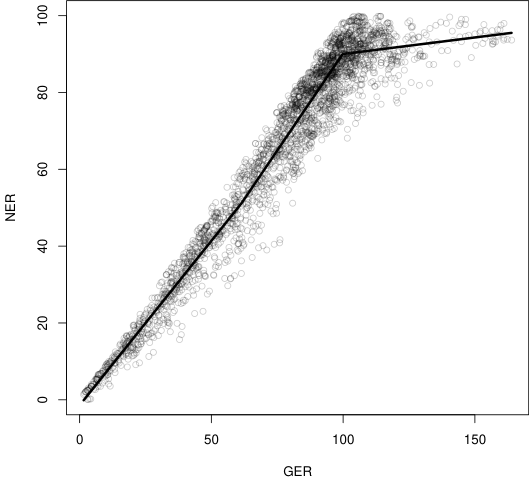

data/processed/pdf/images/2401.01872v2/img-1.png 10 KB


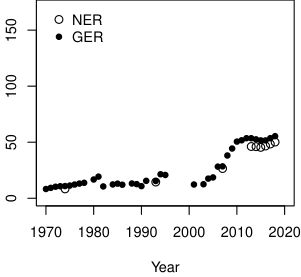

data/processed/pdf/images/2401.01872v2/img-10.png 12 KB


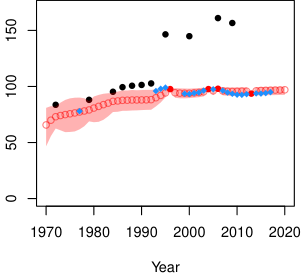

data/processed/pdf/images/2401.01872v2/img-11.png 12 KB


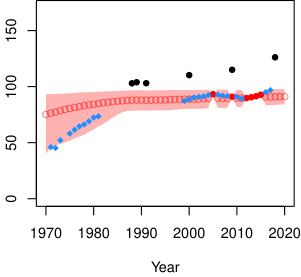

data/processed/pdf/images/2401.01872v2/img-12.png 11 KB


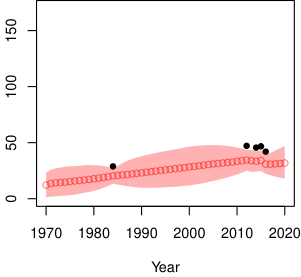

data/processed/pdf/images/2401.01872v2/img-13.png 15 KB


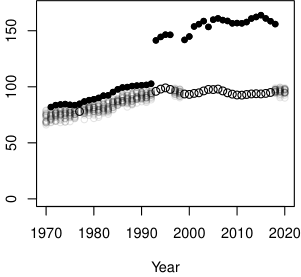

In [19]:
# (corpus) Eyeball a few extracted figures — the check that caught the real bugs.
from IPython.display import Image, display

paths = sorted(glob.glob(f"{PROCESSED_DIR}/images/*/img-*.png"))[:6]
if not paths:
    print("no extracted figures yet")
for path in paths:
    print(path, f"{os.path.getsize(path)/1024:.0f} KB")
    display(Image(filename=path, width=380))

---
# Part 10 — Decision log

| # | Decision | Why | Trade-off accepted |
| --- | --- | --- | --- |
| 1 | Figures and tables are first-class output | 37% of benchmark queries need non-text | Most of the parser's complexity sits in asset handling |
| 2 | Treat upstream counts as a sanity band, not a target | Upstream parse quality is uneven | No exact ground truth to score against |
| 3 | Emit sections, not retrieval chunks | p90 section is 10.9k chars | Downstream must sub-chunk |
| 4 | PyMuPDF as the engine | The structure is in the file; fast, local, gives bboxes | AGPL licence |
| 5 | No LLM for the text layer | Determinism, no fabrication, bboxes required | None material |
| 6 | Flag scanned pages, don't OCR yet | ~1 doc in 43 | Those documents parse thin until handled |
| 7 | Recursive XY-cut for reading order | Two-column papers interleave otherwise | Degrades to y-order when no clean gutter |
| 8 | Span-level heading split | Headings run into the paragraph in this corpus | More code than a block-level test |
| 9 | Heading level from numbering depth | Typography is uniform, numbering is not | Unnumbered headings fall back to size |
| 10 | Drop repeated margin text | Furniture broke sentences and forged sections | Two conditions needed to stay safe |
| 11 | Extract raster *and* vector figures | Most figures here are vector, not bitmaps | Vector figures are rendered, not native |
| 12 | Prose measured in words, not characters | An axis-tick row is long but wordless | Tuned threshold (5 words) |
| 13 | Validate figures visually | Counts called a blank-image run a success | Manual step |
| 14 | ONNX layout model for tables | 1.0 → 3.3 tables/doc; grid is geometry | +150 MB deps, 5× slower parse |
| 15 | VLM for figure descriptions only | No deterministic path from pixels to meaning | Per-image cost; non-determinism |
| 16 | Enrichment is separate and cached | Parse stays free and reproducible | Two stages to run |
| 17 | Gemini Flash-class default, pluggable | Cheapest capable tier; volatile choice | Adapter indirection |

### Known limitations

- **Table structure is recovered, not guaranteed.** `refine` splits merged rows well, but
  multi-level spanning headers flatten, and merged cells repeat their value across the span in
  markdown. `to_html()` preserves the real colspan/rowspan if that matters downstream.
- **Bibliographies produce spurious sections** where italic journal names look like run-in
  headings. Harmless, but it inflates the section count.
- **Scanned documents parse thin.** Flagged via `needs_ocr`, not yet handled.
- **Figure merging is threshold-based.** Two genuinely separate figures 10 pt apart with no caption
  between them will merge. Rare in practice; the caption barrier catches the normal case.
- **Licensing.** Both PyMuPDF and `pymupdf-layout` are AGPL-or-commercial. Fine for research;
  needs a licence decision before shipping a product.

### What I would do next, in order

1. Run the full corpus parse (~42 min) and re-check the density table against the reference band.
2. Build the enrichment stage, run it on ~50 documents, and read the descriptions before spending
   on all 1000.
3. Score retrieval on the text-only query subset versus the image-and-table subsets separately.
   That comparison — not any parsing metric — is what says whether the multimodal path earns
   its cost.